## Sommaire
Navigation rapide vers les sections du notebook.

- [Partie 1 - Regression logistique multiclasse basique](#partie-1---regression-logistique-multiclasse-basique)
- [Partie 2 - Limitation de l eparpillement des classes](#partie-2---limitation-de-l-eparpillement-des-classes)
- [Partie 3 - Regression logistique avec balanced](#partie-3---regression-logistique-avec-balanced)
- [Partie 4 - Regression logistique avec CV en 5 folds](#partie-4---regression-logistique-avec-cv-en-5-folds)
- [Partie 5 - RN basique sans optimisation](#partie-5---rn-basique-sans-optimisation)

In [52]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier



In [4]:
df = pd.read_csv(r"c:\Users\AsgharAli Thomas\Documents\RFID2\ds_Tx_Rx(1).csv")
df.shape

(4411, 292)

In [5]:
import numpy as np
import pandas as pd

def calculate_localization_errors(y_pred_cv, df, X_test, Nx, Ny, h, voxel_center, random_seed=42):
    """
    Calcule les erreurs de localisation (RMSE, moyenne, médiane, max)
    entre les coordonnées prédites et réelles.
    """
    np.random.seed(random_seed)

    true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy()

    errors = []
    pred_coords = []
    true_coords_list = []

    for pred_id, true_xyz in zip(y_pred_cv, true_coords):
        pred_xyz = voxel_center(pred_id, Nx, Ny, h)
        err = np.linalg.norm(true_xyz - pred_xyz)

        errors.append(err)
        pred_coords.append(pred_xyz)
        true_coords_list.append(true_xyz)

    errors = np.array(errors)
    rmse = float(np.sqrt(np.mean(errors ** 2)))

    return {
        "mean_error": errors.mean(),
        "rmse": rmse,
        "median_error": np.median(errors),
        "max_error": errors.max(),
        "predicted_coords": np.array(pred_coords),
        "true_coords": np.array(true_coords_list)
    }

def analyze_prediction_errors(y_test, y_pred_cv, xyz_test_cv, predA3_cv, threshold=1.3, random_seed=42):
    """
    Analyse les erreurs de prédiction entre les coordonnées réelles et prédites.
    """
    np.random.seed(random_seed)

    rows_diff = []

    for class_true, class_pred, xyz_true, xyz_pred in zip(
        np.asarray(y_test).astype(int),
        np.asarray(y_pred_cv).astype(int),
        xyz_test_cv,
        predA3_cv
    ):
        dx = float(xyz_pred[0] - xyz_true[0])
        dy = float(xyz_pred[1] - xyz_true[1])
        dz = float(xyz_pred[2] - xyz_true[2])
        dist = float(np.linalg.norm([dx, dy, dz]))

        rows_diff.append({
            "class_id_true": int(class_true),
            "class_id_pred": int(class_pred),
            "x_true": float(xyz_true[0]),
            "y_true": float(xyz_true[1]),
            "z_true": float(xyz_true[2]),
            "x_pred": float(xyz_pred[0]),
            "y_pred": float(xyz_pred[1]),
            "z_pred": float(xyz_pred[2]),
            "dx": dx,
            "dy": dy,
            "dz": dz,
            "distance": dist
        })

    df_diff = pd.DataFrame(rows_diff)
    df_diff_threshold = df_diff[df_diff["distance"] > threshold]

    stats = df_diff_threshold[[
        "class_id_true", "class_id_pred", "dx", "dy", "dz", "distance"
    ]].describe()

    return df_diff, df_diff_threshold, stats

On introduit les variables x, y, z. On fait via str split

In [6]:
if "xyz" in df.columns:
    xyz_split = df["xyz"].astype(str).str.split("__", expand=True)
    if xyz_split.shape[1] >= 3:
        df[["x", "y", "z"]] = xyz_split.iloc[:, :3]

required = ["x", "y", "z"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Colonnes manquantes dans df: {missing}")

for c in required:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=required).copy()
df = df.reset_index(drop=True)

print("Shape df:", df.shape)
df[["x", "y", "z"]].head()

Shape df: (4411, 292)


,x,y,z
0,1.82,2.51,0.05
1,10.10,3.82,1.29
2,10.34,3.33,0.05
3,10.51,3.26,0.05
4,10.71,3.92,1.57


On veut maintenant, crées des voxels de taille 1 en 3D. x-> i, y-> j, z-> k
ici les classes n'ont pas de sens, mais en baseline on peut tester pour voir les resultats que cela peut donner.


In [7]:
X = df
X.shape[1]

292

In [63]:
import numpy as np
import pandas as pd
### voxels
h = 1  # taille du voxel

for c in ["x", "y", "z"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["x", "y", "z"]).copy()

df["i"] = np.floor(df["x"] / h).astype(int)
df["j"] = np.floor(df["y"] / h).astype(int)
df["k"] = np.floor(df["z"] / h).astype(int)

Nx = df["i"].max() + 1 # nombres de voxels en x, y, zdf["class_id"] = df["i"] + Nx * df["j"] + Nx * Ny * df["k"]
target = df["class_id"]
y=target
Ny = df["j"].max() + 1
Nk = df["k"].max() + 1

df["class_id"] = df["i"] + Nx * df["j"] + Nx * Ny * df["k"]
target = df["class_id"]
### voxels

X = df.drop(columns=[
    # Coordonnées et ground truth
    "i", "j", "k", "x", "y", "z", "xyz", "polar",
    # Distances tag-antenne (leakage)
    "D_041A9F60", "D_041A9F61", "D_0F17B312", "D_0F17B313",
    "PORT_1__NONE", "PORT_2__NONE", "PORT_3__NONE", "PORT_4__NONE",    "D_nearestAnt", "nearestD", "nearestAnt",  "041A9F60__NONE", "041A9F61__NONE", "0F173B12__NONE", "0F173B13__NONE",
    # Autres métadonnées potentiellement liées à la position
    "class_id", "filename", "run_id",  # Si présentes
    # Identifiants (optionnel, selon ton modèle)
    "EPC", "tagID",  # À exclure si non utiles
], errors="ignore")

# Retirer toutes les colonnes non numeriques pour eviter l erreur du scaler
non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
X = X.drop(columns=non_numeric_cols, errors="ignore")




X_small = X.copy()

print("Nombre de classes :", target.nunique())
print("Nombre final de features RSSI :", X.shape[1])
print("Nombre de features RSSI selectionnees :", X_small.shape[1])

Nombre de classes : 74
Nombre final de features RSSI : 276
Nombre de features RSSI selectionnees : 276


In [9]:
X.shape[1]

276

In [10]:
df['class_id'].nunique()

74

Nombre de classes: 74
Min/Max par classe: 10 / 160
Ratio de disparite (max/min): 16.00
Coefficient de variation: 0.587


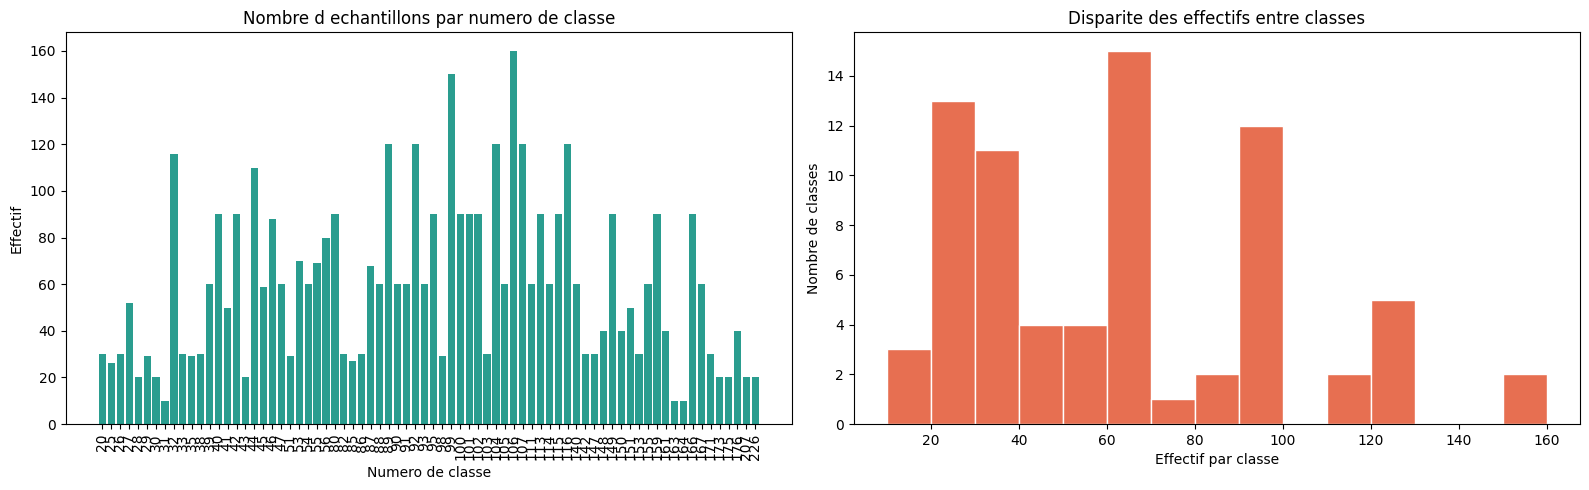

In [11]:
import matplotlib.pyplot as plt

class_counts = target.value_counts().sort_index()

min_count = int(class_counts.min())
max_count = int(class_counts.max())
mean_count = float(class_counts.mean())
std_count = float(class_counts.std(ddof=0))
imbalance_ratio = max_count / max(min_count, 1)
cv = std_count / mean_count if mean_count > 0 else np.nan

print(f"Nombre de classes: {class_counts.shape[0]}")
print(f"Min/Max par classe: {min_count} / {max_count}")
print(f"Ratio de disparite (max/min): {imbalance_ratio:.2f}")
print(f"Coefficient de variation: {cv:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(class_counts.index.astype(str), class_counts.values, color="#2a9d8f")
axes[0].set_title("Nombre d echantillons par numero de classe")
axes[0].set_xlabel("Numero de classe")
axes[0].set_ylabel("Effectif")
axes[0].tick_params(axis="x", labelrotation=90)

axes[1].hist(class_counts.values, bins=15, color="#e76f51", edgecolor="white")
axes[1].set_title("Disparite des effectifs entre classes")
axes[1].set_xlabel("Effectif par classe")
axes[1].set_ylabel("Nombre de classes")

plt.tight_layout()
plt.show()

Pour l'instant on fait une classif basique mais on pourrait aussi essayer en normalisant standars scaler ne regle pas le desiquilibre de classe. Donc deuxieme pîste d'amélioratino


In [12]:
# Verification: class_id est cree a partir de la position voxel (i, j, k)
check_cols = ["xyz","x", "y", "z", "i", "j", "k", "class_id"]
display(df[check_cols].head(10))

labels_uniques = np.sort(df["class_id"].unique())
print("Nombre de labels uniques:", len(labels_uniques))
print("Premiers labels tries:", labels_uniques[:10])



,xyz,x,y,z,i,j,k,class_id
0,1.82__2.51__0.05,1.82,2.51,0.05,1,2,0,25
1,10.1__3.82__1.29,10.10,3.82,1.29,10,3,1,106
2,10.34__3.33__0.05,10.34,3.33,0.05,10,3,0,46
3,10.51__3.26__0.05,10.51,3.26,0.05,10,3,0,46
4,10.71__3.92__1.57,10.71,3.92,1.57,10,3,1,106
5,10.72__3.5__0.05,10.72,3.50,0.05,10,3,0,46
6,10.79__3.89__1.57,10.79,3.89,1.57,10,3,1,106
7,10.98__1.98__1.1300000000000001,10.98,1.98,1.13,10,1,1,82
8,11.01__3.87__1.08,11.01,3.87,1.08,11,3,1,107
9,11.16__3.95__1.07,11.16,3.95,1.07,11,3,1,107


Nombre de labels uniques: 74
Premiers labels tries: [20 25 26 27 28 29 30 31 32 33]


In [13]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)


print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (3528, 276)
Test: (883, 276)


In [14]:
from sklearn.model_selection import GroupShuffleSplit

# Anti-fuite: on separe par groupe de position xyz
groups = df.loc[X_small.index, "xyz"].astype(str) if "xyz" in df.columns else df.loc[X.index].index.astype(str)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_small, target, groups=groups))

X_train_small, X_test_small = X_small.iloc[train_idx], X_small.iloc[test_idx]
y_train_small, y_test_small = target.iloc[train_idx], target.iloc[test_idx]

print("Train:", X_train_small.shape)
print("Test:", X_test_small.shape)
print("Groupes train:", groups.iloc[train_idx].nunique())
print("Groupes test:", groups.iloc[test_idx].nunique())

Train: (3529, 276)
Test: (882, 276)
Groupes train: 355
Groupes test: 89


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

num_features = X_train_scaled.shape[1]
num_classes = target.nunique()

print("num_features =", num_features)
print("num_classes =", num_classes)

num_features = 276
num_classes = 74


## Partie 1 - Regression logistique multiclasse basique
Modele baseline.

In [16]:
from sklearn.linear_model import LogisticRegression

RLog = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)

RLog.fit(X_train_scaled, y_train)

y_pred = RLog.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred)

print("Logistic Regression accuracy:", acc_lr)

Logistic Regression accuracy: 0.217440543601359


In [17]:
def decode_class_id(class_id, Nx, Ny):
    k = class_id // (Nx * Ny)
    remainder = class_id % (Nx * Ny)

    j = remainder // Nx
    i = remainder % Nx

    return i, j, k

In [18]:

def voxel_center(class_id, Nx, Ny, h):
    i, j, k = decode_class_id(class_id, Nx, Ny)

    x = (i + 0.5) * h
    y = (j + 0.5) * h
    z = (k + 0.5) * h

    return np.array([x, y, z])

In [19]:
metrics_lr = calculate_localization_errors(
    y_pred_cv=y_pred,
    df=df,
    X_test=X_test,
    Nx=Nx,
    Ny=Ny,
    h=h,
    voxel_center=voxel_center,
    random_seed=42
)

predA3 = metrics_lr["predicted_coords"]
xyz_test = metrics_lr["true_coords"]
errors = np.linalg.norm(xyz_test - predA3, axis=1)
rmse = float(metrics_lr["rmse"])

print("Erreur moyenne :", metrics_lr["mean_error"])
print("RMSE :", rmse)
print("Erreur mediane :", metrics_lr["median_error"])
print("Erreur max :", metrics_lr["max_error"])

Erreur moyenne : 1.4757956133067958
RMSE : 1.7922452813043952
Erreur mediane : 1.270747811330006
Erreur max : 7.957047191012505


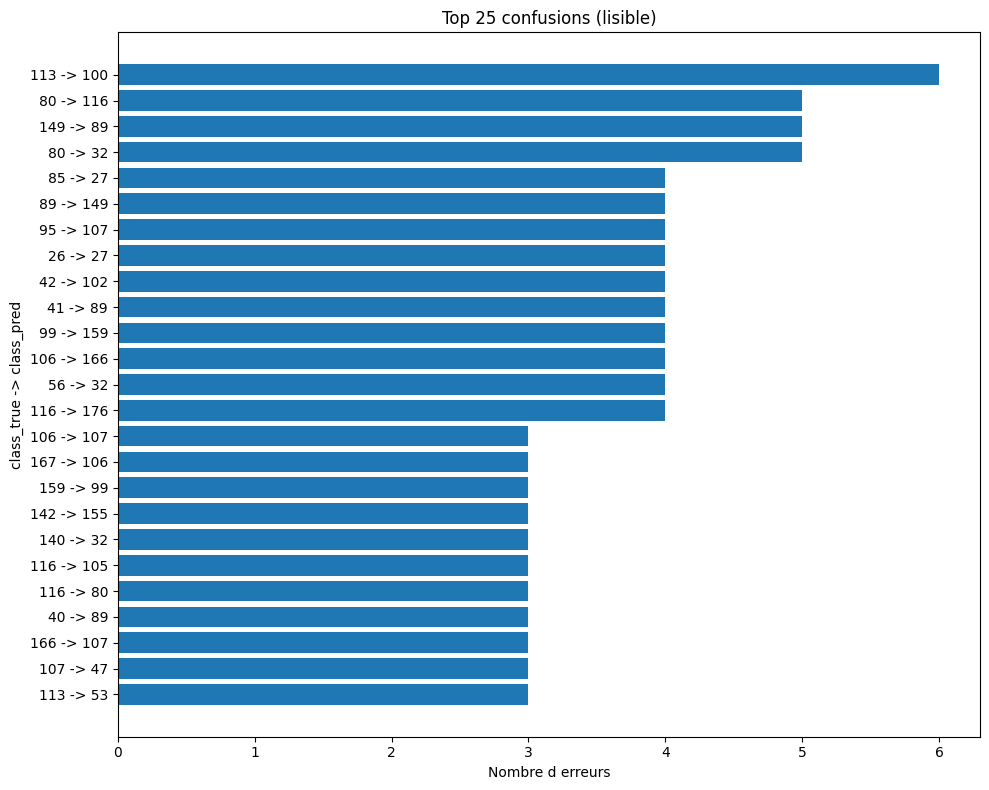

In [20]:
y_true = np.asarray(y_test).astype(int)
y_hat = np.asarray(y_pred).astype(int)

if y_true.shape[0] != y_hat.shape[0]:
    raise ValueError("y_test et y_pred n ont pas la meme taille.")

class_errors = pd.DataFrame({
    "class_true": y_true,
    "class_pred": y_hat,
})
class_errors = class_errors[class_errors["class_true"] != class_errors["class_pred"]].copy()

if class_errors.empty:
    print("Aucune erreur de class_id a afficher.")
else:
    confusion_err = (
        class_errors.groupby(["class_true", "class_pred"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    # 1) Top confusions en barres horizontales (plus lisible)
    top_n = 25
    top_err = confusion_err.head(top_n).copy()
    top_err["pair"] = top_err["class_true"].astype(str) + " -> " + top_err["class_pred"].astype(str)
    top_err = top_err.sort_values("count", ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(top_err["pair"], top_err["count"])
    plt.title(f"Top {top_n} confusions (lisible)")
    plt.xlabel("Nombre d erreurs")
    plt.ylabel("class_true -> class_pred")
    plt.tight_layout()
    plt.show()

In [21]:
df_diff, df_diff_1m, stats_diff_1m = analyze_prediction_errors(
    y_test=y_test,
    y_pred_cv=y_pred,
    xyz_test_cv=xyz_test,
    predA3_cv=predA3,
    threshold=1.0,
    random_seed=42
)

print("Nombre total de lignes:", len(df_diff))
print("Nombre d'erreurs > 1 m:", len(df_diff_1m))

display(df_diff_1m.head(20))

print(stats_diff_1m)

Nombre total de lignes: 883
Nombre d'erreurs > 1 m: 566


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
0,91,32,7.86,2.99,1.10,8.5,2.5,0.5,0.64,-0.49,-0.60,1.004838
1,105,44,9.30,3.70,1.67,8.5,3.5,0.5,-0.80,-0.20,-1.17,1.431398
3,100,113,4.52,3.67,1.34,5.5,4.5,1.5,0.98,0.83,0.16,1.294179
4,53,42,5.55,4.09,0.42,6.5,3.5,0.5,0.95,-0.59,0.08,1.121160
6,149,41,5.67,2.44,2.22,5.5,3.5,0.5,-0.17,1.06,-1.72,2.027535
8,93,45,9.57,2.71,1.96,9.5,3.5,0.5,-0.07,0.79,-1.46,1.661505
9,114,90,6.55,4.02,1.86,6.5,2.5,1.5,-0.05,-1.52,-0.36,1.562850
12,151,93,7.86,2.99,2.40,9.5,2.5,1.5,1.64,-0.49,-0.90,1.933830
13,46,27,10.51,3.26,0.37,3.5,2.5,0.5,-7.01,-0.76,0.13,7.052276
14,41,40,5.68,3.49,0.70,4.5,3.5,0.5,-1.18,0.01,-0.20,1.196871


       class_id_true  class_id_pred          dx          dy          dz  \
count     566.000000     566.000000  566.000000  566.000000  566.000000   
mean       96.054770      83.540636   -0.098216   -0.121025   -0.111290   
std        43.867889      44.144505    1.626551    1.050001    1.002581   
min        20.000000      20.000000   -7.690000   -3.020000   -2.710000   
25%        54.000000      42.000000   -0.890000   -0.860000   -0.850000   
50%        98.500000      89.000000    0.090000   -0.130000   -0.200000   
75%       115.000000     107.000000    0.850000    0.660000    0.670000   
max       226.000000     226.000000    4.460000    2.980000    2.480000   

         distance  
count  566.000000  
mean     1.968203  
std      0.953627  
min      1.001199  
25%      1.307172  
50%      1.758209  
75%      2.260913  
max      7.957047  


faudrait dig sur pq cette data donne ces erreurs maisjsp cmt faire 

On réessaie le même modèle mais cette fois ci avec X small


In [22]:
scaler = StandardScaler()

X_train_small_scaled = scaler.fit_transform(X_train_small)
X_test_small_scaled = scaler.transform(X_test_small)

num_features = X_train_small_scaled.shape[1]
num_classes = target.nunique()

print("num_features =", num_features)
print("num_classes =", num_classes)

num_features = 276
num_classes = 74


In [23]:
from sklearn.linear_model import LogisticRegression

RLog = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)

RLog.fit(X_train_small_scaled, y_train_small)

y_pred = RLog.predict(X_test_small_scaled)
acc_lr = accuracy_score(y_test_small, y_pred)

print("Logistic Regression accuracy:", acc_lr)

Logistic Regression accuracy: 0.15419501133786848


aucun interet de continuer au vu de l'accuracy je pense.

## Partie 2 - Limitation de l eparpillement des classes
Reduction des classes surrepresentees; impact faible observe.

In [24]:
# Proportion de chaque class_id dans un DataFrame
df_prop_class = (
    df["class_id"]
    .value_counts()
    .rename_axis("class_id")
    .reset_index()
    .sort_values("class_id")
    .reset_index(drop=True)
)

print("Nombre de classes:", df_prop_class.shape[0])

display(df_prop_class.max())
mean = df_prop_class["class_id"].mean()
print("Moyenne:", mean)


Nombre de classes: 74


class_id    226
count       160
dtype: int64

Moyenne: 96.01351351351352


In [25]:
df_prop_class = (
    df["class_id"]
    .value_counts()
    .rename_axis("class_id")
    .reset_index(name="count")
)

print("Nombre de classes:", df_prop_class.shape[0])

# afficher les classes les plus représentées
display(df_prop_class.sort_values("count", ascending=True).head(20))

Nombre de classes: 74


,class_id,count
72,163,10
73,164,10
71,31,10
65,43,20
64,30,20
66,173,20
68,207,20
67,28,20
69,226,20
70,175,20


## Partie 3 - Regression logistique avec balanced
Test avec class_weight="balanced" pour compenser le desequilibre.

In [26]:
from sklearn.linear_model import LogisticRegression

RLog_balenced = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42
)

RLog_balenced.fit(X_train_scaled, y_train)

y_pred_balenced = RLog_balenced.predict(X_test_scaled)
acc_lr_balenced = accuracy_score(y_test, y_pred_balenced)

print("Logistic Regression accuracy:", acc_lr_balenced)

Logistic Regression accuracy: 0.19818799546998866


etonnament l'accuracy descends ... néanmoins ce n'est pas une metrics fiable on va tester d'avantage.


In [27]:
metrics_balanced = calculate_localization_errors(
    y_pred_cv=y_pred_balenced,
    df=df,
    X_test=X_test,
    Nx=Nx,
    Ny=Ny,
    h=h,
    voxel_center=voxel_center,
    random_seed=42
)

predA3_balenced = metrics_balanced["predicted_coords"]
xyz_test_balenced = metrics_balanced["true_coords"]
errors = np.linalg.norm(xyz_test_balenced - predA3_balenced, axis=1)
rmse = float(metrics_balanced["rmse"])

print("Erreur moyenne :", metrics_balanced["mean_error"])
print("RMSE :", rmse)
print("Erreur mediane :", metrics_balanced["median_error"])
print("Erreur max :", metrics_balanced["max_error"])

Erreur moyenne : 1.5883462570553826
RMSE : 1.9942733415495986
Erreur mediane : 1.3256319247815362
Erreur max : 9.903262088827095


In [28]:
df_diff_balenced, df_diff_balenced_1p7m, stats_balanced_3m = analyze_prediction_errors(
    y_test=y_test,
    y_pred_cv=y_pred_balenced,
    xyz_test_cv=xyz_test_balenced,
    predA3_cv=predA3_balenced,
    threshold=3.0,
    random_seed=42
)

print("Nombre total de lignes:", len(df_diff_balenced))
print("Nombre d erreurs > 1.7 m:", len(df_diff_balenced_1p7m))

display(df_diff_balenced_1p7m.head(20))

print(stats_balanced_3m)

Nombre total de lignes: 883
Nombre d erreurs > 1.7 m: 75


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
13,46,25,10.51,3.26,0.37,1.5,2.5,0.5,-9.01,-0.76,0.13,9.042931
15,53,226,5.55,4.09,0.42,10.5,3.5,3.5,4.95,-0.59,3.08,5.859778
38,176,142,8.56,4.52,2.12,10.5,1.5,2.5,1.94,-3.02,0.38,3.609487
51,149,85,5.67,2.44,2.22,1.5,2.5,1.5,-4.17,0.06,-0.72,4.232127
59,56,80,8.56,4.52,0.83,8.5,1.5,1.5,-0.06,-3.02,0.67,3.094010
62,32,47,8.56,2.48,0.70,11.5,3.5,0.5,2.94,1.02,-0.20,3.118333
99,39,55,3.76,3.33,0.37,7.5,4.5,0.5,3.74,1.17,0.13,3.920893
100,102,159,6.83,3.36,1.02,3.5,3.5,2.5,-3.33,0.14,1.48,3.646766
111,42,86,6.83,3.36,0.37,2.5,2.5,1.5,-4.33,-0.86,1.13,4.556907
118,155,25,11.19,2.26,2.53,1.5,2.5,0.5,-9.69,0.24,-2.03,9.903262


       class_id_true  class_id_pred         dx         dy         dz  \
count      75.000000      75.000000  75.000000  75.000000  75.000000   
mean       89.106667      69.093333  -1.933467  -0.443867  -0.113333   
std        43.692900      58.594846   3.906189   1.423555   1.226958   
min        30.000000      20.000000  -9.690000  -3.020000  -3.040000   
25%        46.000000      26.000000  -4.750000  -1.305000  -0.840000   
50%        93.000000      46.000000  -2.970000  -0.590000  -0.170000   
75%       116.000000      83.500000   1.940000   0.790000   0.450000   
max       207.000000     226.000000   4.950000   2.980000   3.080000   

        distance  
count  75.000000  
mean    4.417196  
std     1.736798  
min     3.031402  
25%     3.214780  
50%     3.646766  
75%     4.919391  
max     9.903262  


on observe pas des résultat proprement meilleurs, néanmoins on peut également tester d'autre méthode.

## Partie 4 - Regression logistique avec CV en 5 folds
Evaluation par validation croisee (5 folds).

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

RLog_cv = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    random_state=53
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(RLog_cv, X_train, y_train, cv=cv)

print("CV accuracy scores:", cv_scores)
print("CV mean accuracy:", cv_scores.mean())

# entrainement final
RLog_cv.fit(X_train, y_train)

y_pred_cv = RLog_cv.predict(X_test)
acc_lr_cv = accuracy_score(y_test, y_pred_cv)

print("Test accuracy:", acc_lr_cv)

CV accuracy scores: [0.22804533 0.19546742 0.2407932  0.20425532 0.22553191]
CV mean accuracy: 0.21881863661021034
Test accuracy: 0.24462061155152887


In [30]:
coef_df = pd.DataFrame(
    RLog_cv.coef_,
    columns=X_train.columns
)
coef_df.max()

max__rssi__24.0__041A9F60__NONE__PORT_1__NONE                     1.360059
max__rssi__24.0__041A9F60__NONE__PORT_2__NONE                     0.773049
max__rssi__24.0__041A9F60__NONE__PORT_3__NONE                     1.120436
max__rssi__24.0__041A9F60__NONE__PORT_4__NONE                     0.661811
max__rssi__24.0__041A9F61__NONE__PORT_1__NONE                     1.860253
                                                                    ...   
max__Delta_rssi__31.5__PORT_3__NONE__PORT_3__NONE|PORT_2__NONE    1.001498
max__Delta_rssi__31.5__PORT_3__NONE__PORT_3__NONE|PORT_4__NONE    1.218472
max__Delta_rssi__31.5__PORT_4__NONE__PORT_4__NONE|PORT_1__NONE    0.955103
max__Delta_rssi__31.5__PORT_4__NONE__PORT_4__NONE|PORT_2__NONE    0.596073
max__Delta_rssi__31.5__PORT_4__NONE__PORT_4__NONE|PORT_3__NONE    1.257065
Length: 276, dtype: float64

In [31]:
metrics_cv = calculate_localization_errors(
    y_pred_cv=y_pred_cv,
    df=df,
    X_test=X_test,
    Nx=Nx,
    Ny=Ny,
    h=h,
    voxel_center=voxel_center,
    random_seed=42
)

predA3_cv = metrics_cv["predicted_coords"]
xyz_test_cv = metrics_cv["true_coords"]
errors = np.linalg.norm(xyz_test_cv - predA3_cv, axis=1)
rmse_cv = float(metrics_cv["rmse"])

print("Erreur moyenne :", metrics_cv["mean_error"])
print("RMSE :", rmse_cv)
print("Erreur mediane :", metrics_cv["median_error"])
print("Erreur max :", metrics_cv["max_error"])

Erreur moyenne : 1.3849146049335896
RMSE : 1.7527465584907722
Erreur mediane : 1.1690166808048548
Erreur max : 7.957047191012505


In [32]:
df_diff_cv, df_diff_cv_1p3m, stats_cv_1p3m = analyze_prediction_errors(
    y_test=y_test,
    y_pred_cv=y_pred_cv,
    xyz_test_cv=xyz_test_cv,
    predA3_cv=predA3_cv,
    threshold=1.3,
    random_seed=42
)

print("Nombre total de lignes:", len(df_diff_cv))
print("Nombre d erreurs > 1.3 m:", len(df_diff_cv_1p3m))

display(df_diff_cv_1p3m.head(20))

print(stats_cv_1p3m)

Nombre total de lignes: 883
Nombre d erreurs > 1.3 m: 377


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
1,105,44,9.30,3.70,1.67,8.5,3.5,0.5,-0.80,-0.20,-1.17,1.431398
2,95,106,11.59,2.78,1.28,10.5,3.5,1.5,-1.09,0.72,0.22,1.324726
11,111,159,3.20,4.47,1.67,3.5,3.5,2.5,0.30,-0.97,0.83,1.311411
12,151,44,7.86,2.99,2.40,8.5,3.5,0.5,0.64,0.51,-1.90,2.068744
13,46,27,10.51,3.26,0.37,3.5,2.5,0.5,-7.01,-0.76,0.13,7.052276
16,90,40,6.34,2.69,1.43,4.5,3.5,0.5,-1.84,0.81,-0.93,2.215085
21,105,106,9.01,3.85,1.67,10.5,3.5,1.5,1.49,-0.35,-0.17,1.539968
26,102,40,6.83,3.36,1.67,4.5,3.5,0.5,-2.33,0.14,-1.17,2.611015
27,25,99,1.82,2.51,0.37,3.5,3.5,1.5,1.68,0.99,1.13,2.253752
28,88,101,4.41,2.39,1.71,5.5,3.5,1.5,1.09,1.11,-0.21,1.569809


       class_id_true  class_id_pred          dx          dy          dz  \
count     377.000000     377.000000  377.000000  377.000000  377.000000   
mean       97.058355      80.564987   -0.357401   -0.124562   -0.184775   
std        46.483946      37.198313    1.958436    1.159862    0.986403   
min        20.000000      20.000000   -7.730000   -3.020000   -3.040000   
25%        53.000000      41.000000   -1.190000   -0.990000   -0.970000   
50%        95.000000      92.000000   -0.010000   -0.190000   -0.210000   
75%       140.000000     106.000000    0.850000    0.810000    0.480000   
max       226.000000     176.000000    3.270000    2.980000    2.040000   

         distance  
count  377.000000  
mean     2.245588  
std      1.129393  
min      1.300500  
25%      1.570891  
50%      1.951563  
75%      2.480847  
max      7.957047  


In [33]:
print(*X_train.columns, sep="\n")

max__rssi__24.0__041A9F60__NONE__PORT_1__NONE
max__rssi__24.0__041A9F60__NONE__PORT_2__NONE
max__rssi__24.0__041A9F60__NONE__PORT_3__NONE
max__rssi__24.0__041A9F60__NONE__PORT_4__NONE
max__rssi__24.0__041A9F61__NONE__PORT_1__NONE
max__rssi__24.0__041A9F61__NONE__PORT_2__NONE
max__rssi__24.0__041A9F61__NONE__PORT_3__NONE
max__rssi__24.0__041A9F61__NONE__PORT_4__NONE
max__rssi__24.0__0F173B12__NONE__PORT_1__NONE
max__rssi__24.0__0F173B12__NONE__PORT_2__NONE
max__rssi__24.0__0F173B12__NONE__PORT_3__NONE
max__rssi__24.0__0F173B12__NONE__PORT_4__NONE
max__rssi__24.0__0F173B13__NONE__PORT_1__NONE
max__rssi__24.0__0F173B13__NONE__PORT_2__NONE
max__rssi__24.0__0F173B13__NONE__PORT_3__NONE
max__rssi__24.0__0F173B13__NONE__PORT_4__NONE
max__rssi__24.0__PORT_1__NONE__PORT_1__NONE
max__rssi__24.0__PORT_1__NONE__PORT_2__NONE
max__rssi__24.0__PORT_1__NONE__PORT_3__NONE
max__rssi__24.0__PORT_1__NONE__PORT_4__NONE
max__rssi__24.0__PORT_2__NONE__PORT_1__NONE
max__rssi__24.0__PORT_2__NONE__PORT_2__NONE


### Moyenne des probabilités pour améliorer la localisation

Actuellement, le modèle prédit un **voxel** via une régression logistique multinomiale.  
La position \((x,y,z)\) est ensuite obtenue en prenant **le centre du voxel le plus probable (argmax)**.

Cependant, l’argmax utilise uniquement la classe la plus probable et **ignore l’information contenue dans le reste de la distribution de probabilités**.

L’idée est donc d’utiliser les probabilités prédites pour calculer **une moyenne pondérée des centres des voxels** :

$$
(\hat{x}, \hat{y}, \hat{z}) = \sum_{k} p_k \,(x_k, y_k, z_k)
$$

où :

- $p_k$ est la probabilité prédite pour le voxel $k$
- $(x_k, y_k, z_k)$ est le centre du voxel $k$

Cette approche permet de **réduire l’erreur de discrétisation liée aux voxels**.  
Si le modèle hésite entre plusieurs voxels voisins, la moyenne pondérée permet de prédire une position **intermédiaire**, souvent plus proche de la position réelle que celle obtenue avec l’argmax.

In [34]:
RLog_cv_mean = LogisticRegression(
    max_iter=3000,
    solver="lbfgs",
    random_state=53
)

folds = KFold(n_splits=8, shuffle=True, random_state=42)
cv_scores_mean = cross_val_score(RLog_cv, X_train_scaled, y_train, cv=folds)

print("CV accuracy scores:", cv_scores_mean)
print("CV mean accuracy:", cv_scores_mean.mean())

# entraînement final
RLog_cv_mean.fit(X_train_scaled, y_train)

distrib_proba = RLog_cv_mean.predict_proba(X_test_scaled)




CV accuracy scores: [0.1814059  0.21315193 0.1723356  0.18594104 0.20861678 0.1723356
 0.17687075 0.19047619]
CV mean accuracy: 0.18764172335600907


In [35]:
classes = RLog_cv_mean.classes_.astype(float)   # ex: [0, 1, 2, ...] ou labels réels
classes.shape

(74,)

In [36]:
distrib_proba[1].shape

(74,)

In [37]:
y_pred_cv_mean = []
n = len(distrib_proba)

for i in range(n):
    a = np.sum(distrib_proba[i] * classes)
    y_pred_cv_mean.append(a)

centers = np.array([voxel_center(int(c), Nx, Ny, h) for c in classes], dtype=float) # on construit la table des centres de chaques voxels
predA3_cv_mean = distrib_proba @ centers # on fait le produit matriciel entre les proba et les centres pour obtenir la position prédite en continu (non discrète)


predA3_cv_mean.shape


(883, 3)

In [38]:

true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy(dtype=float)


errors = np.linalg.norm(true_coords - predA3_cv_mean, axis=1)
rmse = float(np.sqrt(np.mean(errors ** 2)))

print("Erreur moyenne :", errors.mean())
print("RMSE :", rmse)
print("Erreur mediane :", np.median(errors))
print("Erreur max :", errors.max())

Erreur moyenne : 1.310370241453701
RMSE : 1.5337860345377001
Erreur mediane : 1.1351702710256424
Erreur max : 4.780982731141439


In [39]:
rows_diff = []

for class_true, class_pred_mean, xyz_true, xyz_pred_cv_mean in zip(
    np.asarray(y_test).astype(int),
    np.asarray(y_pred_cv_mean, dtype=float),
    xyz_test,
    predA3_cv_mean
):
    dx = float(xyz_pred_cv_mean[0] - xyz_true[0])
    dy = float(xyz_pred_cv_mean[1] - xyz_true[1])
    dz = float(xyz_pred_cv_mean[2] - xyz_true[2])
    dist = float(np.linalg.norm([dx, dy, dz]))

    rows_diff.append({
        "class_id_true": int(class_true),
        "class_id_pred_mean": float(class_pred_mean),
        "x_true": float(xyz_true[0]),
        "y_true": float(xyz_true[1]),
        "z_true": float(xyz_true[2]),
        "x_pred": float(xyz_pred_cv_mean[0]),
        "y_pred": float(xyz_pred_cv_mean[1]),
        "z_pred": float(xyz_pred_cv_mean[2]),
        "dx": dx,
        "dy": dy,
        "dz": dz,
        "distance": dist
    })

df_diff_cv_mean = pd.DataFrame(rows_diff)

print("Nombre total de lignes:", len(df_diff_cv_mean))

df_diff_cv_mean_1m = df_diff_cv_mean[df_diff_cv_mean["distance"] > 2]
print("Nombre d erreurs > 1 m:", len(df_diff_cv_mean_1m))

display(df_diff_cv_mean_1m.head(20))

print(df_diff_cv_mean_1m[[
    "class_id_true",
    "class_id_pred_mean",
    "dx",
    "dy",
    "dz",
    "distance"
]].describe())

Nombre total de lignes: 883
Nombre d erreurs > 1 m: 153


,class_id_true,class_id_pred_mean,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
5,27,78.720403,3.36,2.09,0.70,5.617199,3.134812,1.199758,2.257199,1.044812,0.499758,2.536993
6,149,41.037568,5.67,2.44,2.22,5.499978,3.499381,0.500750,-0.170022,1.059381,-1.719250,2.026577
13,46,78.316100,10.51,3.26,0.37,7.204211,3.010020,1.191527,-3.305789,-0.249980,0.821527,3.415500
15,53,139.324852,5.55,4.09,0.42,7.840221,3.003874,2.198969,2.290221,-1.086126,1.778969,3.096694
27,25,71.190334,1.82,2.51,0.37,5.050940,3.065275,1.097601,3.230940,0.555275,0.727601,3.358081
38,176,104.784464,8.56,4.52,2.12,10.001121,3.217846,1.544487,1.441121,-1.302154,-0.575513,2.025747
48,151,57.727746,7.40,2.87,2.84,7.916379,3.077533,0.823016,0.516379,0.207533,-2.016984,2.092353
59,56,80.456112,8.56,4.52,0.83,8.500000,1.562196,1.495163,-0.060000,-2.957804,0.665163,3.032268
64,25,70.063910,1.82,2.51,0.37,4.266108,3.156388,1.073686,2.446108,0.646388,0.703686,2.626106
65,56,61.621426,8.56,4.52,0.83,8.502635,1.982192,1.097208,-0.057365,-2.537808,0.267208,2.552481


       class_id_true  class_id_pred_mean          dx          dy          dz  \
count     153.000000          153.000000  153.000000  153.000000  153.000000   
mean       87.529412           86.343047    0.226104    0.009885    0.094883   
std        46.477082           28.468656    2.324523    1.037228    1.015990   
min        25.000000           23.417486   -4.113612   -3.019989   -2.438031   
25%        46.000000           70.780254   -2.049779   -0.619995   -0.609592   
50%        88.000000           79.303081    0.839964    0.157879    0.179347   
75%       113.000000           95.000003    2.059179    0.736260    0.821527   
max       207.000000          225.998828    4.709689    2.717967    2.379980   

         distance  
count  153.000000  
mean     2.671707  
std      0.622191  
min      2.006579  
25%      2.215716  
50%      2.456339  
75%      3.055885  
max      4.780983  


In [ ]:
n = min(len(df_diff_cv_mean), len(df_diff_cv_mean))

left = df_diff_cv[["class_id_true", "class_id_pred", "distance"]].iloc[:n].reset_index(drop=False)
right = df_diff_cv_mean[[ "class_id_pred_mean", "distance"]].iloc[:n].reset_index(drop=True)

comp = pd.DataFrame({
    "class_id_true": left["class_id_true"].astype(int),
    "class_id_pred_cv": left["class_id_pred"].astype(int),
    "class_id_pred_cv_mean": right["class_id_pred_mean"].astype(float),
    "distance_cv": left["distance"].astype(float),
    "distance_cv_mean": right["distance"].astype(float),
})

comp["delta_class_id_pred"] = comp["class_id_pred_cv"] - comp["class_id_pred_cv_mean"]
comp["delta_distance"] = comp["distance_cv"] - comp["distance_cv_mean"]

# Garder uniquement les lignes differentes entre les deux approches
tol = 1e-12
mask_diff = (
    (comp["delta_class_id_pred"].abs() > tol)
    | (comp["delta_distance"].abs() > tol)
)

df_comp = comp.loc[mask_diff].reset_index(drop=True)

print("Lignes comparees:", len(comp))
print("Lignes differentes:", len(df_comp))
display(df_comp.head(20))
print(df_comp[["delta_class_id_pred", "delta_distance"]].describe())

Lignes comparees: 883
Lignes differentes: 883


,class_id_true,class_id_pred_cv,class_id_pred_cv_mean,distance_cv,distance_cv_mean,delta_class_id_pred,delta_distance
0,91,32,70.646050,1.004838,0.375710,-38.646050,0.629128
1,105,44,71.372847,1.431398,0.928900,-27.372847,0.502498
2,95,106,99.852095,1.324726,0.613117,6.147905,0.711609
3,100,113,111.816193,1.294179,1.291207,1.183807,0.002972
4,53,42,70.984699,1.121160,0.850524,-28.984699,0.270636
5,27,27,78.720403,0.477179,2.536993,-51.720403,-2.059814
6,149,89,41.037568,0.742226,2.026577,47.962432,-1.284351
7,101,101,102.923134,0.723187,0.592574,-1.923134,0.130613
8,93,93,84.464941,0.510490,1.709468,8.535059,-1.198978
9,114,114,94.025024,0.602080,1.503596,19.974976,-0.901516


       delta_class_id_pred  delta_distance
count           883.000000      883.000000
mean             -7.546806        0.074544
std              29.491566        0.951521
min            -124.998828       -3.095931
25%             -28.221124       -0.298553
50%              -2.801302        0.032001
75%               9.204324        0.432000
max             119.999770        4.570869


### Decision Tree :
Je pense qu'il peut être judicieux de vraiment tester les arbres de décision. dans un premier temps on a vu que Extra Treefonctionnait donc c une voix encouragente  et je pense que pour comprendre mieux comme les datas sont séparés faire ce type d'algo est bénéfique pour mieux comprendre et intérpreter les erreurs

première implémentation naïves:

In [42]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_dt.fit(X_train_scaled, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [43]:


print('Profondeur :', model_dt.get_depth())
print('Nombre de noeuds :', model_dt.tree_.node_count)
print('Nombre de feuilles :', model_dt.get_n_leaves())
print('Critere par defaut :', model_dt.criterion)



Profondeur : 19
Nombre de noeuds : 3521
Nombre de feuilles : 1761
Critere par defaut : entropy


In [67]:
from sklearn.model_selection import cross_validate
cv_resultas = cross_validate(model_dt, X, y, cv=5, return_train_score =True)
cv_resultas

{'fit_time': array([2.57676554, 2.60247898, 2.63377142, 2.58560753, 2.46287298]),
 'score_time': array([0.00471354, 0.00373936, 0.0030005 , 0.        , 0.00374579]),
 'test_score': array([0.1200453 , 0.09297052, 0.11111111, 0.1292517 , 0.10657596]),
 'train_score': array([1., 1., 1., 1., 1.])}

In [68]:
y_pred_DT = model_dt.predict(X_test_scaled)

Overfit réel : idée pruning?

In [65]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate

# 1. Définis et entraîne le modèle sur X_train
model_dt_max = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2
)
model_dt_max.fit(X_train_scaled, y_train)

# 2. Validation croisée sur X_train (pour évaluer la généralisation)
cv_results = cross_validate(
    model_dt_max,
    X_train_scaled,
    y_train,
    cv=5,
    return_train_score=True
)

# 3. Prédictions sur X_test (pour l'évaluation finale)
y_pred_DT = model_dt_max.predict(X_test_scaled)  # ✅ Ici, y_pred_DT contient les prédictions


In [66]:
cv_results

{'fit_time': array([1.77280927, 1.87913871, 1.72340918, 1.96975923, 1.88159013]),
 'score_time': array([0.00100327, 0.00099921, 0.00200486, 0.        , 0.00107622]),
 'test_score': array([0.12747875, 0.12464589, 0.11048159, 0.1177305 , 0.10921986]),
 'train_score': array([0.59425939, 0.63040397, 0.61445783, 0.62132483, 0.60007085])}

In [70]:


print('Profondeur :', model_dt_max.get_depth())
print('Nombre de noeuds :', model_dt_max.tree_.node_count)
print('Nombre de feuilles :', model_dt_max.get_n_leaves())
print('Critere par defaut :', model_dt_max.criterion)



Profondeur : 10
Nombre de noeuds : 1207
Nombre de feuilles : 604
Critere par defaut : entropy


profondeur 19 vs 10


In [71]:
path = model_dt.cost_complexity_pruning_path(X_train_scaled, y_train)
ccp_alphas = path.ccp_alphas
print('Nombre de coefficients alpha :', len(ccp_alphas))
print('Premiers alphas :', ccp_alphas[:10])
print('alpha_0 :', ccp_alphas[0])

Nombre de coefficients alpha : 1747
Premiers alphas : [0.         0.00051157 0.00056689 0.00056689 0.00056689 0.00056689
 0.00056689 0.00056689 0.00056689 0.00056689]
alpha_0 : 0.0


In [76]:
cv_results = []
for alphas in ccp_alphas[::10]:
    model_dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=alphas )
    score_alpha=cross_validate(model_dt_pruned, X_train_scaled, y_train, cv=5, return_train_score=True)
    cv_results.append(score_alpha['test_score'].mean())

cv_results


[np.float64(0.12527997106865169),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.12300805657685895),
 np.float64(0.

In [80]:
type(ccp_alphas)

numpy.ndarray

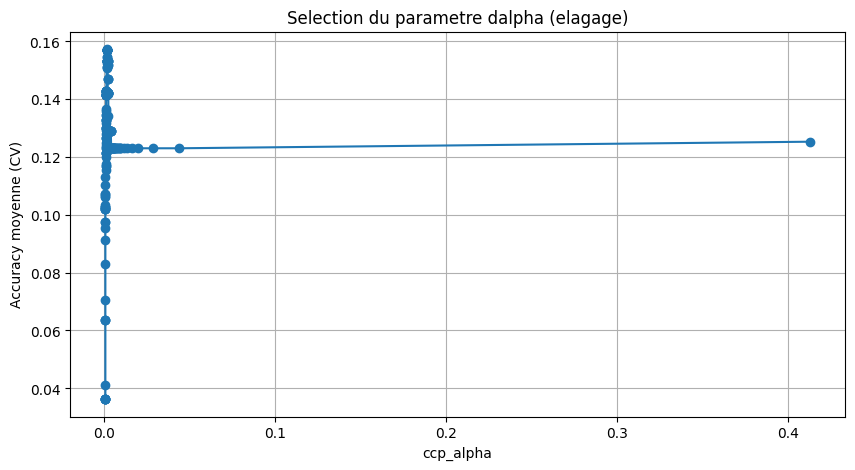

Meilleur alpha : 0.000567 avec CV accuracy : 0.1573


In [89]:
scores = list(score_alpha.values())
plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas[::-10], cv_results[:], marker='o')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy moyenne (CV)')
plt.title('Selection du parametre dalpha (elagage)')
plt.grid(True)
plt.show()
best_idx = int(np.argmax(cv_results[:-1]))
best_alpha = ccp_alphas[best_idx]
best_cv_score = cv_results[best_idx]
print(f"Meilleur alpha : {best_alpha:.6f} avec CV accuracy : {best_cv_score:.4f}")



In [90]:
best_idx = int(np.argmax(cv_scores[:-1]))
best_alpha = ccp_alphas[best_idx]
best_cv_score = cv_scores[best_idx]

clf_prune = DecisionTreeClassifier(random_state=0, ccp_alpha=best_alpha)
clf_prune.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [92]:
y_pred_pruned = clf_prune.predict(X_test_scaled)
acc_pruned = accuracy_score(y_test, y_pred_pruned)
acc_pruned

c:\Users\AsgharAli Thomas\Documents\RFID2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.11325028312570781

In [96]:
metrics_dt_pruned = calculate_localization_errors(y_pred_pruned, df, X_test, Nx, Ny, h, voxel_center)
predA3 = metrics_dt_pruned["predicted_coords"]
xyz_test = metrics_dt_pruned["true_coords"]
errors = np.linalg.norm(xyz_test - predA3, axis=1)
rmse = float(metrics_dt_pruned["rmse"])
print("Erreur moyenne :", metrics_dt_pruned["mean_error"])
print("RMSE :", rmse)



Erreur moyenne : 2.189782741028914
RMSE : 2.7807383101010914


In [102]:
df_diff_DT_pruned, df_diff_dt_pp, stats_balanced_pruned_3m= analyze_prediction_errors(y_test, y_pred_pruned, xyz_test, predA3_cv, threshold=2)

print("Nombre total de lignes:", len(df_diff_DT_pruned))
print("Nombre d erreurs > 1.7 m:", len(df_diff_dt_pp))

display(df_diff_dt_pp.head(20))

print(stats_balanced_pruned_3m)

Nombre total de lignes: 883
Nombre d erreurs > 1.7 m: 181


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
12,151,113,7.86,2.99,2.40,8.5,3.5,0.5,0.64,0.51,-1.90,2.068744
13,46,27,10.51,3.26,0.37,3.5,2.5,0.5,-7.01,-0.76,0.13,7.052276
16,90,27,6.34,2.69,1.43,4.5,3.5,0.5,-1.84,0.81,-0.93,2.215085
26,102,27,6.83,3.36,1.67,4.5,3.5,0.5,-2.33,0.14,-1.17,2.611015
27,25,85,1.82,2.51,0.37,3.5,3.5,1.5,1.68,0.99,1.13,2.253752
34,43,27,7.26,3.59,0.99,10.5,3.5,0.5,3.24,-0.09,-0.49,3.278079
38,176,27,8.56,4.52,2.12,11.5,3.5,1.5,2.94,-1.02,-0.62,3.173074
48,151,29,7.40,2.87,2.84,8.5,2.5,0.5,1.10,-0.37,-2.34,2.611992
51,149,149,5.67,2.44,2.22,3.5,3.5,1.5,-2.17,1.06,-0.72,2.520099
52,56,32,8.87,4.79,0.05,8.5,2.5,0.5,-0.37,-2.29,0.45,2.362943


       class_id_true  class_id_pred          dx          dy          dz  \
count     181.000000     181.000000  181.000000  181.000000  181.000000   
mean       93.602210      65.635359   -0.898840   -0.264088   -0.221713   
std        45.048946      48.485962    2.579144    1.320780    1.034739   
min        20.000000      20.000000   -7.730000   -3.020000   -3.040000   
25%        53.000000      27.000000   -2.190000   -1.260000   -0.950000   
50%        92.000000      42.000000   -0.370000   -0.210000   -0.250000   
75%       116.000000      92.000000    1.100000    0.750000    0.480000   
max       207.000000     226.000000    3.270000    2.980000    2.040000   

         distance  
count  181.000000  
mean     2.946676  
std      1.291491  
min      2.000825  
25%      2.203497  
50%      2.523232  
75%      3.094010  
max      7.957047  


In [123]:
# Correction robuste comparaison df_diff_dt_pp (pruned) vs df_diff_cv_mean
import pandas as pd
import numpy as np

# Vérification des colonnes et tailles
print("df_diff_dt_pp columns:", df_diff_dt_pp.columns)
print("df_diff_cv_mean columns:", df_diff_cv_mean.columns)
print("len(df_diff_dt_pp):", len(df_diff_dt_pp))
print("len(df_diff_cv_mean):", len(df_diff_cv_mean))

n = min(len(df_diff_dt_pp), len(df_diff_cv_mean))

left = df_diff_dt_pp[["class_id_true", "class_id_pred", "distance"]].iloc[:n].reset_index(drop=True)
right = df_diff_cv_mean[["class_id_pred_mean", "distance"]].iloc[:n].reset_index(drop=True)

comp = pd.DataFrame({
    "class_id_true": left["class_id_true"].astype(int),
    "class_id_pred_pruned": left["class_id_pred"].astype(int),
    "class_id_pred_cv_mean": right["class_id_pred_mean"].astype(int),
    "distance_pruned": left["distance"].astype(float),
    "distance_cv_mean": right["distance"].astype(float),
})

comp["delta_class_id_pred"] = comp["class_id_pred_pruned"] - comp["class_id_pred_cv_mean"]
comp["delta_distance"] = comp["distance_pruned"] - comp["distance_cv_mean"]

# Filtrer uniquement les erreurs où la distance cv_mean > 1.5
comp_filtered = comp[comp["distance_cv_mean"] > 1.5].reset_index(drop=True)

# Garder uniquement les lignes différentes entre les deux approches
tol = 1e-12
mask_diff = (
    (comp_filtered["delta_class_id_pred"].abs() > tol)
    | (comp_filtered["delta_distance"].abs() > tol)
)

df_comp = comp_filtered.loc[mask_diff].reset_index(drop=True)

print("Lignes comparées (filtrées):", len(comp_filtered))
print("Lignes différentes:", len(df_comp))
display(df_comp.head(20))
print(df_comp[["delta_class_id_pred", "delta_distance"]].describe())


df_diff_dt_pp columns: Index(['class_id_true', 'class_id_pred', 'x_true', 'y_true', 'z_true',
       'x_pred', 'y_pred', 'z_pred', 'dx', 'dy', 'dz', 'distance'],
      dtype='object')
df_diff_cv_mean columns: Index(['class_id_true', 'class_id_pred_mean', 'x_true', 'y_true', 'z_true',
       'x_pred', 'y_pred', 'z_pred', 'dx', 'dy', 'dz', 'distance'],
      dtype='object')
len(df_diff_dt_pp): 181
len(df_diff_cv_mean): 883
Lignes comparées (filtrées): 61
Lignes différentes: 61


,class_id_true,class_id_pred_pruned,class_id_pred_cv_mean,distance_pruned,distance_cv_mean,delta_class_id_pred,delta_distance
0,43,27,78,3.278079,2.536993,-51,0.741085
1,176,27,41,3.173074,2.026577,-14,1.146497
2,149,149,84,2.520099,1.709468,65,0.810631
3,56,32,94,2.362943,1.503596,-62,0.859347
4,25,27,86,2.253752,1.962849,-59,0.290903
5,56,32,78,2.047657,3.415500,-46,-1.367843
6,32,27,139,3.343561,3.096694,-112,0.246867
7,116,106,104,2.085641,1.678865,2,0.406776
8,140,27,71,3.502413,3.358081,-44,0.144332
9,40,148,92,2.233294,1.548799,56,0.684495


       delta_class_id_pred  delta_distance
count            61.000000       61.000000
mean            -15.983607        0.530142
std              59.724225        1.414429
min            -134.000000       -2.314155
25%             -54.000000        0.010913
50%             -28.000000        0.482867
75%              14.000000        0.918165
max             153.000000        6.160307


### Baaging 